<a href="https://colab.research.google.com/github/MuhammadAqsandy/PracticalLinearAlgebra/blob/main/11_Chapter11_General_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: General Least Squares

**Topics Covered:**
- Overdetermined Systems
- Least Squares Formula
- Normal Equations
- Residuals
- Regression via Least Squares


## Overdetermined System

In [2]:
import numpy as np
# More equations than unknowns - no exact solution
A = np.array([[1,1],[1,2],[1,3],[1,4]], dtype=float)
b = np.array([2, 3, 5, 4], dtype=float)
print('A shape:', A.shape, '(4 equations, 2 unknowns)')
print('No exact solution - use least squares')

A shape: (4, 2) (4 equations, 2 unknowns)
No exact solution - use least squares


## Least Squares via Normal Equations

In [3]:
# x = (A.T @ A)^-1 @ A.T @ b
A = np.array([[1,1],[1,2],[1,3],[1,4]], dtype=float)
b = np.array([2, 3, 5, 4], dtype=float)
x = np.linalg.inv(A.T @ A) @ A.T @ b
print('Least squares solution:', np.round(x, 4))
print('Intercept:', round(x[0],4), ', Slope:', round(x[1],4))

Least squares solution: [1.5 0.8]
Intercept: 1.5 , Slope: 0.8


## Least Squares via np.linalg.lstsq

In [4]:
A = np.array([[1,1],[1,2],[1,3],[1,4]], dtype=float)
b = np.array([2, 3, 5, 4], dtype=float)
x, residuals, rank, sv = np.linalg.lstsq(A, b, rcond=None)
print('Solution:', np.round(x, 4))
print('Residuals:', residuals)
print('Rank:', rank)

Solution: [1.5 0.8]
Residuals: [1.8]
Rank: 2


## Plotting the Fit

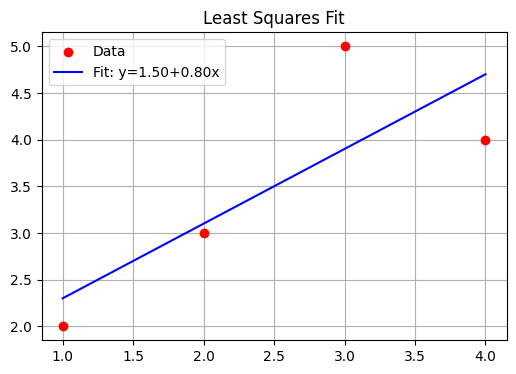

In [6]:
import matplotlib.pyplot as plt
x_data = np.array([1,2,3,4])
y_data = np.array([2,3,5,4])
A = np.column_stack([np.ones_like(x_data), x_data])
coef, _, _, _ = np.linalg.lstsq(A, y_data, rcond=None)
y_fit = A @ coef
plt.figure(figsize=(6,4))
plt.scatter(x_data, y_data, color='red', zorder=5, label='Data')
plt.plot(x_data, y_fit, 'b-', label=f'Fit: y={coef[0]:.2f}+{coef[1]:.2f}x')
plt.legend(); plt.grid(True); plt.title('Least Squares Fit'); plt.show()

## Residuals and R-squared

In [7]:
y_pred = A @ coef
resid = y_data - y_pred
SS_res = np.sum(resid**2)
SS_tot = np.sum((y_data - np.mean(y_data))**2)
R2 = 1 - SS_res/SS_tot
print('Residuals:', np.round(resid, 4))
print('R² score:', round(R2, 4))

Residuals: [-0.3 -0.1  1.1 -0.7]
R² score: 0.64


## 📝 Summary

Chapter 11 addresses overdetermined systems (more equations than unknowns) where no exact solution exists. Least squares finds the solution that minimizes the sum of squared residuals — the closest approximation. The normal equations (A^T A x = A^T b) derive the optimal solution analytically. In practice, np.linalg.lstsq() is preferred over computing the normal equations directly (more numerically stable). This chapter is the mathematical foundation of linear regression in machine learning.